CountVectorizer: (3000, 9709)
TfidfVectorizer: (3000, 9709)
The dimensionality is 9709, which is the number of unique tokens.
classes I think will be separable:  ['sadness', 'joy', 'anger', 'love']


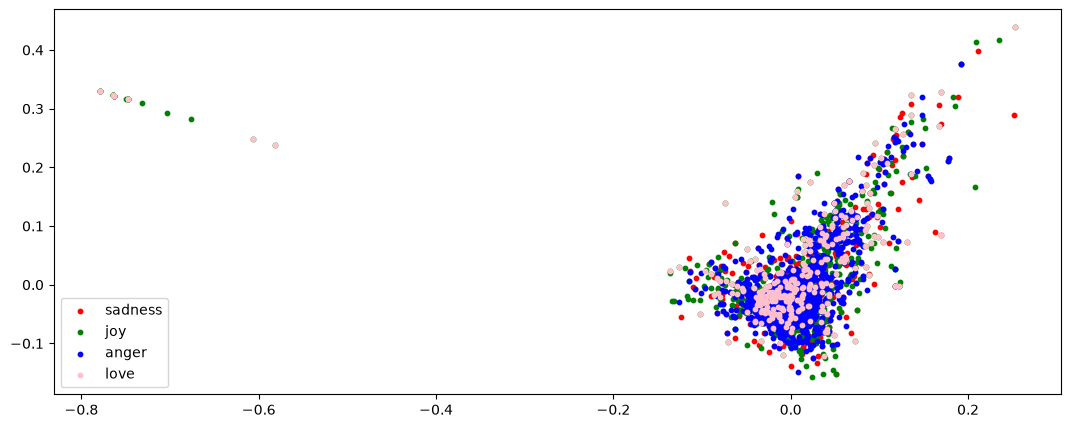

{'ID': '2017-En-11484', 'Tweet': "LGBTQ media should inform, inspire, entertain &amp;unite our community. It shouldn't give platform 2 those whose goal is 2 offend us 4 attention", 'anger': True, 'anticipation': False, 'disgust': True, 'fear': False, 'joy': True, 'love': False, 'optimism': False, 'pessimism': False, 'sadness': False, 'surprise': False, 'trust': False}


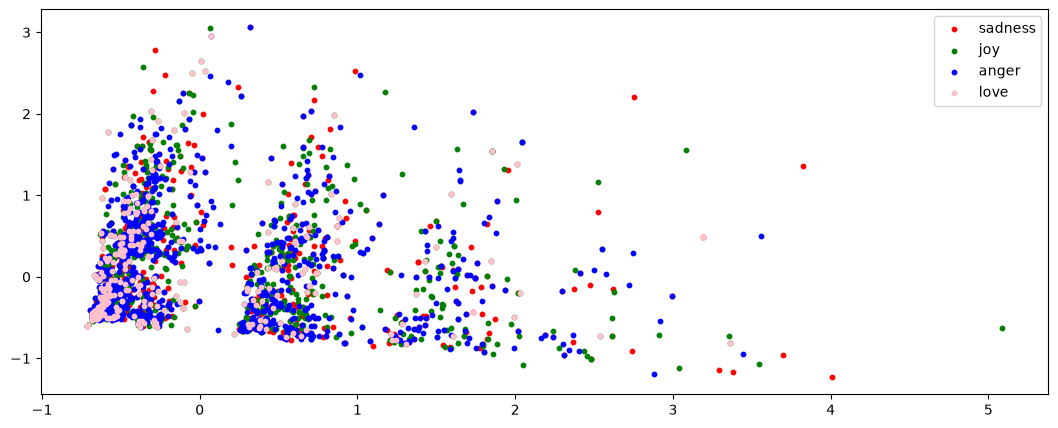

None of the classes are visually separable


In [ ]:
# init
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


data_set = []
tweets = []

with open("text_dataset\\student_12\\train.json", "r", encoding="utf-8") as file:
    for line in file:
        data_set.append(json.loads(line))
        tweets.append(json.loads(line)["Tweet"])

# use the simple countvectorizer and tfidfvectorizer
tweets_count = CountVectorizer().fit_transform(tweets)
print("CountVectorizer:", tweets_count.shape)

tweets_tfidf = TfidfVectorizer().fit_transform(tweets)
print("TfidfVectorizer:", tweets_tfidf.shape)

print("The dimensionality is 9709, which is the number of unique tokens.")

# Pick four classes which you think will be separable. State the four classes
classes = ["sadness","joy","anger","love"]
print("classes I think will be separable: ", classes)

# Perform dimensionality reduction similar to 4(d) with dimensionality reduced to 2
pca_tfidf = PCA(n_components=2).fit_transform(tweets_tfidf)
pca_count = PCA(n_components=2).fit_transform(tweets_count)

# plot  tf-idf features
fig, ax = plt.subplots(1, figsize=(13, 5))

for emotion, color in [
    ("sadness", "red"),
    ("joy", "green"),
    ("anger", "blue"),
    ("love", "pink")
]:
    mask = np.array([line[emotion] for line in data_set])

    ax.scatter(
        pca_tfidf[mask, 0],
        pca_tfidf[mask, 1],
        c=color,
        label=emotion,
        s=10
    )
plt.legend()
plt.show()


# plot token count features
fig, ax = plt.subplots(1, figsize=(13, 5))

for emotion, color in [
    ("sadness", "red"),
    ("joy", "green"),
    ("anger", "blue"),
    ("love", "pink")
]:
    mask = np.array([line[emotion] for line in data_set])

    ax.scatter(
        pca_count[mask, 0],
        pca_count[mask, 1],
        c=color,
        label=emotion,
        s=10
    )
plt.legend()
plt.show()

# Which classes (if any) are visually separable (i.e., non-overlapping) for both plots?
print("None of the classes are visually separable")